### Set Up

In [11]:
import numpyro
numpyro.set_host_device_count(4)

import jax
import jax.numpy as jnp
import numpy as np
import sncosmo
from bayesn import SEDmodel
from pathlib import Path
import pandas as pd

from io import BytesIO
import gzip
from astropy.io import fits
from zipfile import ZipFile, BadZipFile

import numpy as np
import matplotlib.pyplot as plt
import sncosmo
from bayesn import SEDmodel

In [2]:
project_root = Path.cwd().parent
lsst_zip = project_root / "data" / "Foundation_DR1.zip"


In [5]:
try:
    with ZipFile(lsst_zip, "r") as archive:
        all_entries = archive.namelist()

    print("Number of ZIP entries:", len(all_entries))
    print(*all_entries[:30], sep="\n")

except FileNotFoundError:
    print(f"File not found: {lsst_zip.resolve()}")

except BadZipFile:
    print("The file exists but is not a valid ZIP archive.")

Number of ZIP entries: 185
Foundation_DR1/
Foundation_DR1/Foundation_DR1_MASTEROTJ08.txt
Foundation_DR1/Foundation_DR1_PS15asb.txt
Foundation_DR1/Foundation_DR1_ASASSN-15od.txt
Foundation_DR1/Foundation_DR1_ASASSN-15bc.txt
Foundation_DR1/Foundation_DR1_PS15mt.txt
Foundation_DR1/Foundation_DR1_PS15bwh.txt
Foundation_DR1/Foundation_DR1_SN2016coj.txt
Foundation_DR1/Foundation_DR1_AT2016gmg.txt
Foundation_DR1/Foundation_DR1_ASASSN-16dw.txt
Foundation_DR1/Foundation_DR1_ASASSN-16ip.txt
Foundation_DR1/Foundation_DR1_ASASSN-16hc.txt
Foundation_DR1/Foundation_DR1_PS16axi.txt
Foundation_DR1/Foundation_DR1_PS15adh.txt
Foundation_DR1/Foundation_DR1_SN2017cpu.txt
Foundation_DR1/Foundation_DR1_ASASSN-16db.txt
Foundation_DR1/Foundation_DR1_ASASSN-15tz.txt
Foundation_DR1/Foundation_DR1_SN2016ayg.txt
Foundation_DR1/Foundation_DR1_PS15bzz.txt
Foundation_DR1/Foundation_DR1_SN2017jl.txt
Foundation_DR1/Foundation_DR1_ATLAS17ajs.txt
Foundation_DR1/Foundation_DR1_PS16cvc.txt
Foundation_DR1/Foundation_DR1_iP

In [6]:
with ZipFile(lsst_zip, "r") as archive:
    all_entries = archive.namelist()

    txt_files = [
        name
        for name in all_entries
        if name.lower().endswith(".txt")
        and "__MACOSX" not in Path(name).parts
        and not Path(name).name.startswith("._")
    ]

print("Real light-curve files:", len(txt_files))
print(*txt_files[:10], sep="\n")

Real light-curve files: 180
Foundation_DR1/Foundation_DR1_MASTEROTJ08.txt
Foundation_DR1/Foundation_DR1_PS15asb.txt
Foundation_DR1/Foundation_DR1_ASASSN-15od.txt
Foundation_DR1/Foundation_DR1_ASASSN-15bc.txt
Foundation_DR1/Foundation_DR1_PS15mt.txt
Foundation_DR1/Foundation_DR1_PS15bwh.txt
Foundation_DR1/Foundation_DR1_SN2016coj.txt
Foundation_DR1/Foundation_DR1_AT2016gmg.txt
Foundation_DR1/Foundation_DR1_ASASSN-16dw.txt
Foundation_DR1/Foundation_DR1_ASASSN-16ip.txt


In [7]:
def decode_text(raw_bytes):
    encodings = [
        "utf-8",
        "utf-8-sig",
        "cp1252",
        "latin-1",
    ]

    for encoding in encodings:
        try:
            return raw_bytes.decode(encoding), encoding
        except UnicodeDecodeError:
            continue

    raise ValueError("Could not decode file using supported encodings.")

In [8]:
def read_snana_text_file(archive, filename):
    """
    Read one SNANA-format text light curve from an open ZIP archive.

    Returns
    -------
    metadata : dict
        Object-level information such as SNID, RA and redshift.

    observations : pandas.DataFrame
        One row per OBS measurement.

    encoding : str
        Text encoding used to decode the file.
    """

    with archive.open(filename) as file:
        raw_bytes = file.read()

    text, encoding = decode_text(raw_bytes)
    lines = text.splitlines()

    metadata = {}
    varlist = None
    observation_rows = []

    for raw_line in lines:
        line = raw_line.strip()

        if not line:
            continue

        if line.startswith("#"):
            continue

        if line.startswith("VARLIST:"):
            varlist = line.split(":", 1)[1].split()
            continue

        if line.startswith("OBS:"):
            if varlist is None:
                raise ValueError(
                    f"OBS row found before VARLIST in {filename}"
                )

            values = line.split(":", 1)[1].split()

            if len(values) != len(varlist):
                raise ValueError(
                    f"{filename}: expected {len(varlist)} values, "
                    f"but found {len(values)} in:\n{line}"
                )

            observation_rows.append(values)
            continue

        if line == "END:":
            break

        if ":" in line:
            key, value = line.split(":", 1)
            metadata[key.strip()] = value.strip()

    if varlist is None:
        raise ValueError(f"No VARLIST found in {filename}")

    observations = pd.DataFrame(
        observation_rows,
        columns=varlist,
    )

    numeric_columns = [
        "MJD",
        "FLUXCAL",
        "FLUXCALERR",
        "MAG",
        "MAGERR",
        "PSF",
    ]

    for column in numeric_columns:
        if column in observations.columns:
            observations[column] = pd.to_numeric(
                observations[column],
                errors="coerce",
            )

    return metadata, observations, encoding

In [12]:
test_file = txt_files[0]

with ZipFile(lsst_zip, "r") as archive:
    test_metadata, test_observations, test_encoding = (
        read_snana_text_file(archive, test_file)
    )

print("File:", test_file)
print("Encoding:", test_encoding)
print("SNID:", test_metadata.get("SNID"))
print("Declared NOBS:", test_metadata.get("NOBS"))
print("Parsed observations:", len(test_observations))

display(test_observations.head())

File: Foundation_DR1/Foundation_DR1_MASTEROTJ08.txt
Encoding: utf-8
SNID: MASTEROTJ08
Declared NOBS: 25
Parsed observations: 25


,MJD,FLT,FIELD,FLUXCAL,FLUXCALERR,MAG,MAGERR,PSF
0,57808.43076,g,NULL,21009.444,366.130,16.694,0.019,2.15
1,57825.34020,g,NULL,5969.606,247.777,18.060,0.045,2.76
2,57831.23762,g,NULL,3690.841,111.695,18.582,0.033,1.59
3,57843.29875,g,NULL,2667.690,145.003,18.935,0.059,2.76
4,57859.29519,g,NULL,1521.568,86.161,19.544,0.061,1.96


In [14]:
all_metadata = []
all_observations = []
failed_files = []

with ZipFile(lsst_zip, "r") as archive:

    for filename in txt_files:
        try:
            metadata, observations, encoding = (
                read_snana_text_file(archive, filename)
            )

            snid = metadata.get(
                "SNID",
                Path(filename).stem,
            )

            observations.insert(0, "SNID", snid)
            observations.insert(1, "SOURCE_FILE", filename)

            all_observations.append(observations)

            all_metadata.append({
                "SNID": snid,
                "SOURCE_FILE": filename,
                "TEXT_ENCODING": encoding,
                **metadata,
            })

        except Exception as error:
            failed_files.append({
                "SOURCE_FILE": filename,
                "ERROR": str(error),
            })

In [15]:
metadata_df = pd.DataFrame(all_metadata)

detections_df = pd.concat(
    all_observations,
    ignore_index=True,
)

failed_df = pd.DataFrame(failed_files)

In [16]:
print("Objects loaded:", len(metadata_df))
print("Observation rows loaded:", len(detections_df))
print("Failed real files:", len(failed_df))

Objects loaded: 180
Observation rows loaded: 5709
Failed real files: 0


In [17]:
display(metadata_df.head())

,SNID,SOURCE_FILE,TEXT_ENCODING,SURVEY,SNTYPE,RA,DECL,MWEBV,FILTERS,REDSHIFT_HELIO,REDSHIFT_CMB,REDSHIFT_FINAL,SEARCH_PEAKMJD,HOSTGAL_LOGMASS,VPEC,VPEC_ERR,PIXSIZE,NOBS,NVAR
0,MASTEROTJ08,Foundation_DR1/Foundation_DR1_MASTEROTJ08.txt,utf-8,FOUNDATION,1,128.2370548,-3.8578969,0.0313 +- 0.0016,griz,0.0305840 +- 0.0001500,0.0315652 +- 0.0001500,0.0315652 +- 0.0001500,57808.43076,6.000 +- 0.100,-140.033,250.000,0.25 # arcsec,25,8
1,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,utf-8,FOUNDATION,1,215.0846629,-9.3009081,0.0456 +- 0.0023,griz,0.0486300 +- 0.0003300,0.0495156 +- 0.0003300,0.0495156 +- 0.0003300,57195.27426,6.000 +- 0.100,277.052,250.000,0.25 # arcsec,30,8
2,ASASSN-15od,Foundation_DR1/Foundation_DR1_ASASSN-15od.txt,utf-8,FOUNDATION,1,35.8049483,-4.5171839,0.0255 +- 0.0013,griz,0.0176030 +- 0.0000130,0.0167840 +- 0.0000130,0.0167840 +- 0.0000130,57255.60389,9.899 +- 0.001,137.894,250.000,0.25 # arcsec,28,8
3,ASASSN-15bc,Foundation_DR1/Foundation_DR1_ASASSN-15bc.txt,utf-8,FOUNDATION,1,61.5609874,-8.8856098,0.0375 +- 0.0019,griz,0.0367150 +- 0.0000970,0.0363880 +- 0.0000970,0.0363880 +- 0.0000970,57046.21469,10.187 +- 0.011,467.851,250.000,0.25 # arcsec,32,8
4,PS15mt,Foundation_DR1/Foundation_DR1_PS15mt.txt,utf-8,FOUNDATION,1,148.6840749,23.1981134,0.0212 +- 0.0011,griz,0.0708500 +- 0.0000880,0.0719258 +- 0.0000880,0.0719258 +- 0.0000880,57105.23788,8.856 +- 0.047,-127.187,250.000,0.25 # arcsec,24,8


In [19]:
metadata_df["NOBS_DECLARED"] = pd.to_numeric(
    metadata_df["NOBS"],
    errors="coerce",
)

parsed_counts = (
    detections_df
    .groupby("SNID")
    .size()
    .rename("NOBS_PARSED")
    .reset_index()
)

nobs_check = metadata_df.merge(
    parsed_counts,
    on="SNID",
    how="left",
)

nobs_mismatches = nobs_check[
    nobs_check["NOBS_DECLARED"]
    != nobs_check["NOBS_PARSED"]
]

print("Objects with an NOBS mismatch:", len(nobs_mismatches))

display(
    nobs_mismatches[
        [
            "SNID",
            "NOBS_DECLARED",
            "NOBS_PARSED",
            "SOURCE_FILE",
        ]
    ]
)

Objects with an NOBS mismatch: 0


,SNID,NOBS_DECLARED,NOBS_PARSED,SOURCE_FILE


In [20]:
detections_df["SNR"] = (
    detections_df["FLUXCAL"]
    / detections_df["FLUXCALERR"]
)

In [21]:
display(
    detections_df[
        [
            "SNID",
            "MJD",
            "FLT",
            "FLUXCAL",
            "FLUXCALERR",
            "SNR",
            "MAG",
            "MAGERR",
        ]
    ].head(20)
)

,SNID,MJD,FLT,FLUXCAL,FLUXCALERR,SNR,MAG,MAGERR
0,MASTEROTJ08,57808.43076,g,21009.444,366.130,57.382471,16.694,0.019
1,MASTEROTJ08,57825.34020,g,5969.606,247.777,24.092656,18.060,0.045
2,MASTEROTJ08,57831.23762,g,3690.841,111.695,33.043923,18.582,0.033
3,MASTEROTJ08,57843.29875,g,2667.690,145.003,18.397481,18.935,0.059
4,MASTEROTJ08,57859.29519,g,1521.568,86.161,17.659591,19.544,0.061
5,MASTEROTJ08,57808.43117,r,20859.204,346.574,60.186869,16.702,0.018
6,MASTEROTJ08,57825.34061,r,10076.315,230.911,43.637224,17.492,0.025
7,MASTEROTJ08,57831.23803,r,7816.771,154.094,50.727290,17.767,0.021
8,MASTEROTJ08,57843.29915,r,5082.476,160.416,31.683099,18.235,0.034
9,MASTEROTJ08,57808.43153,i,12942.264,247.360,52.321572,17.220,0.021


In [22]:
snr3_df = detections_df[
    detections_df["SNR"] > 3
].copy()

print("All observations:", len(detections_df))
print("Observations with SNR > 3:", len(snr3_df))

All observations: 5709
Observations with SNR > 3: 5366


### Examine one transient

In [23]:
snid = "PS15asb"

object_metadata = metadata_df[
    metadata_df["SNID"] == snid
]

object_observations = detections_df[
    detections_df["SNID"] == snid
].sort_values("MJD")

display(object_metadata)
display(object_observations)

,SNID,SOURCE_FILE,TEXT_ENCODING,SURVEY,SNTYPE,RA,DECL,MWEBV,FILTERS,REDSHIFT_HELIO,REDSHIFT_CMB,REDSHIFT_FINAL,SEARCH_PEAKMJD,HOSTGAL_LOGMASS,VPEC,VPEC_ERR,PIXSIZE,NOBS,NVAR,NOBS_DECLARED
1,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,utf-8,FOUNDATION,1,215.0846629,-9.3009081,0.0456 +- 0.0023,griz,0.0486300 +- 0.0003300,0.0495156 +- 0.0003300,0.0495156 +- 0.0003300,57195.27426,6.000 +- 0.100,277.052,250.000,0.25 # arcsec,30,8,30


,SNID,SOURCE_FILE,MJD,FLT,FIELD,FLUXCAL,FLUXCALERR,MAG,MAGERR,PSF,SNR
44,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57166.36042,i,NULL,-2.890,35.478,NaN,13.258,1.72,-0.081459
45,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57166.37342,i,NULL,56.877,36.247,23.113,0.688,1.72,1.569151
46,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57166.38637,i,NULL,30.505,32.373,23.789,1.146,1.52,0.942298
47,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57166.39940,i,NULL,32.558,35.094,23.718,1.164,1.53,0.927737
25,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57195.27426,g,NULL,8079.323,178.252,17.732,0.024,2.17,45.325287
31,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57195.27465,r,NULL,8089.224,155.286,17.730,0.021,1.52,52.092423
37,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57195.27502,i,NULL,4850.825,116.570,18.285,0.026,1.55,41.612979
48,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57195.27538,z,NULL,4423.842,147.164,18.386,0.036,1.45,30.060626
26,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57203.27091,g,NULL,5355.136,213.604,18.178,0.043,2.07,25.070392
32,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57203.27132,r,NULL,5974.526,173.632,18.059,0.031,1.83,34.409130


In [24]:
snid = "PS15asb"

lightcurve = (
    detections_df[detections_df["SNID"] == snid]
    .sort_values("MJD")
    .copy()
)

print(f"Number of observations for {snid}: {len(lightcurve)}")
display(lightcurve.head())

Number of observations for PS15asb: 30


,SNID,SOURCE_FILE,MJD,FLT,FIELD,FLUXCAL,FLUXCALERR,MAG,MAGERR,PSF,SNR
44,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57166.36042,i,NULL,-2.890,35.478,NaN,13.258,1.72,-0.081459
45,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57166.37342,i,NULL,56.877,36.247,23.113,0.688,1.72,1.569151
46,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57166.38637,i,NULL,30.505,32.373,23.789,1.146,1.52,0.942298
47,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57166.39940,i,NULL,32.558,35.094,23.718,1.164,1.53,0.927737
25,PS15asb,Foundation_DR1/Foundation_DR1_PS15asb.txt,57195.27426,g,NULL,8079.323,178.252,17.732,0.024,2.17,45.325287


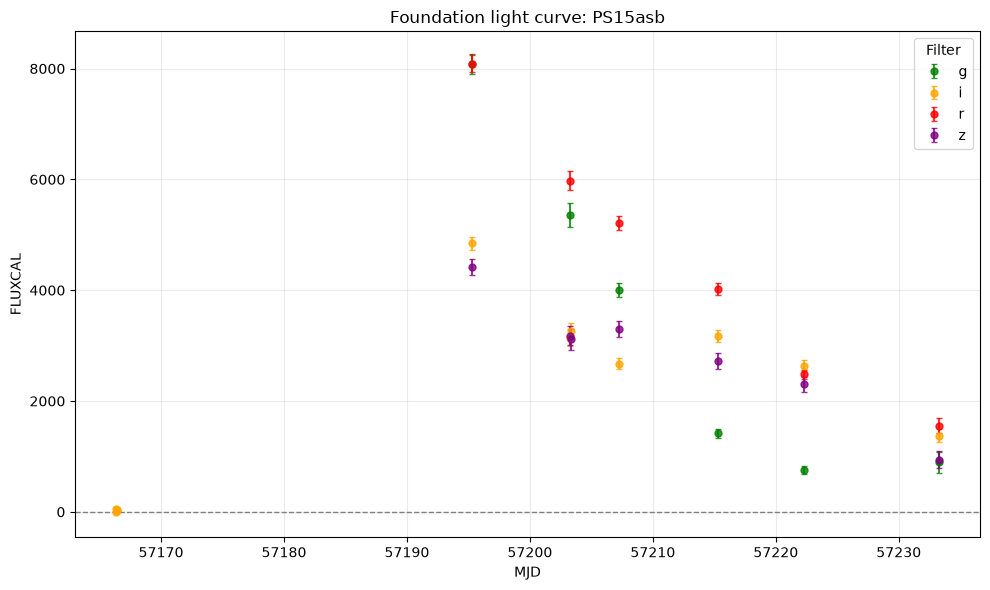

In [25]:
filter_colours = {
    "g": "green",
    "r": "red",
    "i": "orange",
    "z": "purple",
}

fig, ax = plt.subplots(figsize=(10, 6))

for band, band_data in lightcurve.groupby("FLT"):
    ax.errorbar(
        band_data["MJD"],
        band_data["FLUXCAL"],
        yerr=band_data["FLUXCALERR"],
        fmt="o",
        markersize=5,
        capsize=2,
        color=filter_colours.get(band, "black"),
        label=band,
        alpha=0.8,
    )

ax.axhline(0, color="grey", linewidth=1, linestyle="--")

ax.set_xlabel("MJD")
ax.set_ylabel("FLUXCAL")
ax.set_title(f"Foundation light curve: {snid}")
ax.legend(title="Filter")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [26]:
peak_mjd = float(
    metadata_df.loc[
        metadata_df["SNID"] == snid,
        "SEARCH_PEAKMJD",
    ].iloc[0]
)

lightcurve["PHASE"] = lightcurve["MJD"] - peak_mjd

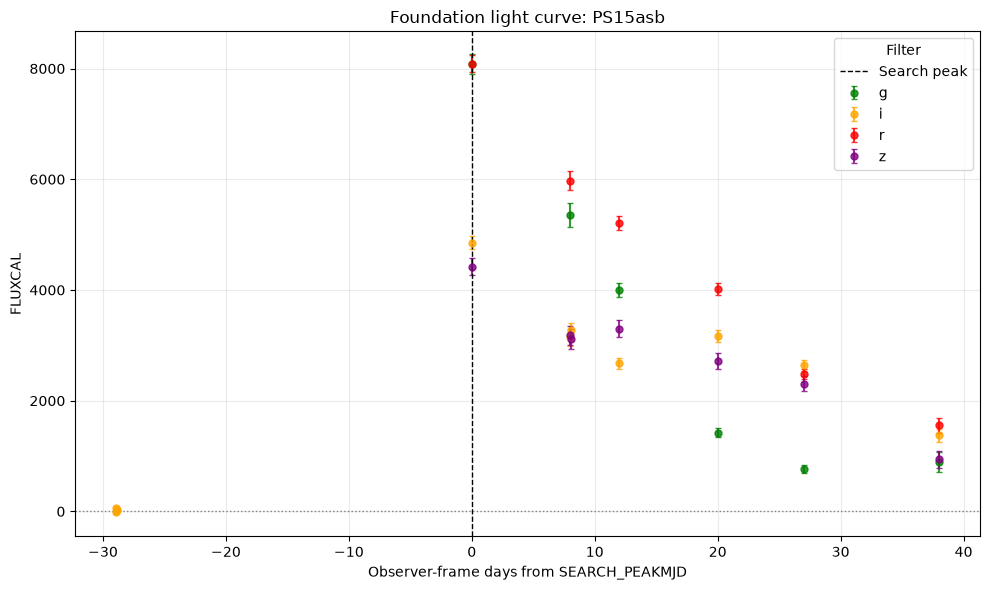

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

for band, band_data in lightcurve.groupby("FLT"):
    ax.errorbar(
        band_data["PHASE"],
        band_data["FLUXCAL"],
        yerr=band_data["FLUXCALERR"],
        fmt="o",
        markersize=5,
        capsize=2,
        color=filter_colours.get(band, "black"),
        label=band,
        alpha=0.8,
    )

ax.axvline(0, color="black", linestyle="--", linewidth=1, label="Search peak")
ax.axhline(0, color="grey", linestyle=":", linewidth=1)

ax.set_xlabel("Observer-frame days from SEARCH_PEAKMJD")
ax.set_ylabel("FLUXCAL")
ax.set_title(f"Foundation light curve: {snid}")
ax.legend(title="Filter")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

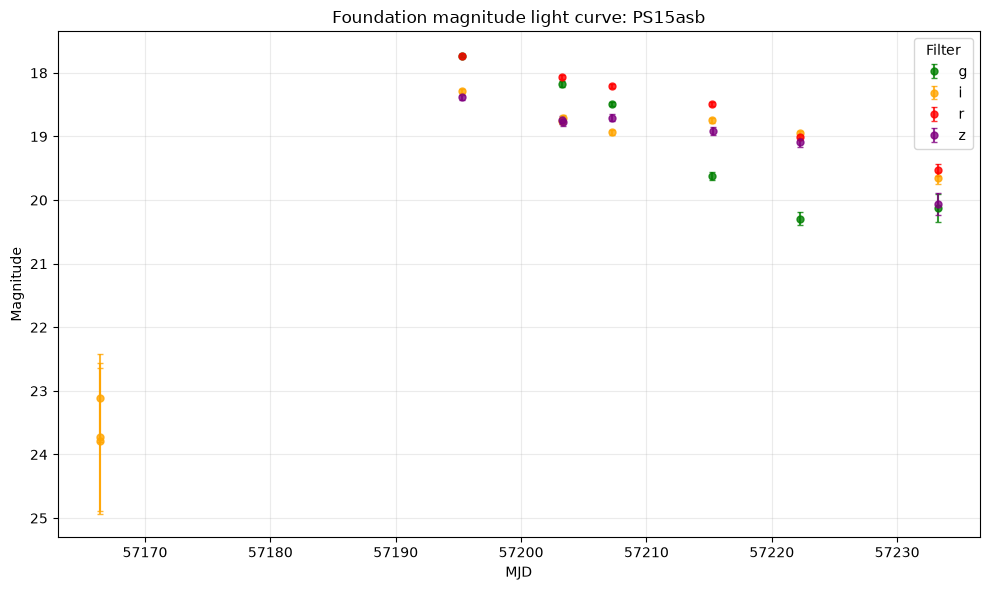

In [28]:
magnitude_data = lightcurve.dropna(
    subset=["MAG", "MAGERR"]
).copy()

fig, ax = plt.subplots(figsize=(10, 6))

for band, band_data in magnitude_data.groupby("FLT"):
    ax.errorbar(
        band_data["MJD"],
        band_data["MAG"],
        yerr=band_data["MAGERR"],
        fmt="o",
        markersize=5,
        capsize=2,
        color=filter_colours.get(band, "black"),
        label=band,
        alpha=0.8,
    )

ax.invert_yaxis()

ax.set_xlabel("MJD")
ax.set_ylabel("Magnitude")
ax.set_title(f"Foundation magnitude light curve: {snid}")
ax.legend(title="Filter")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [29]:
valid_filters = ["g", "r", "i", "z"]

good_rows = (
    detections_df["MJD"].notna()
    & detections_df["FLUXCAL"].notna()
    & detections_df["FLUXCALERR"].notna()
    & (detections_df["FLUXCALERR"] > 0)
    & detections_df["FLT"].isin(valid_filters)
)

clean_detections_df = detections_df[good_rows].copy()

clean_detections_df["SNR"] = (
    clean_detections_df["FLUXCAL"]
    / clean_detections_df["FLUXCALERR"]
)

In [30]:
clean_detections_df["OBS_DAY"] = (
    np.floor(clean_detections_df["MJD"]).astype(int)
)

coverage_df = (
    clean_detections_df.groupby("SNID")
    .agg(
        n_observations=("MJD", "size"),
        n_days=("OBS_DAY", "nunique"),
        n_filters=("FLT", "nunique"),
        lightcurve_span=("MJD", lambda x: x.max() - x.min()),
    )
    .reset_index()
)

display(coverage_df.describe())
display(
    coverage_df.sort_values(
        ["n_filters", "n_days"],
        ascending=False,
    )
)

,n_observations,n_days,n_filters,lightcurve_span
count,180.000000,180.000000,180.0,180.000000
mean,31.716667,8.116667,4.0,80.413023
std,9.101707,2.371325,0.0,94.025809
min,15.000000,4.000000,4.0,20.007970
25%,25.750000,6.000000,4.0,44.973975
50%,30.000000,8.000000,4.0,54.828390
75%,36.000000,9.000000,4.0,71.952375
max,68.000000,18.000000,4.0,709.100540


,SNID,n_observations,n_days,n_filters,lightcurve_span
121,PS15cms,45,18,4,97.03063
101,Gaia16aki,68,17,4,366.02548
26,ASASSN-15so,56,15,4,113.78191
136,PS16em,53,15,4,70.82757
21,ASASSN-15oh,50,14,4,401.07881
...,...,...,...,...,...
172,SN2017coa,19,5,4,46.90881
174,SN2017hn,20,5,4,56.93631
177,SN2017ms,20,5,4,73.72046
80,AT2017lm,16,4,4,47.00483


In [31]:
cols = [
    "SNID",
    "REDSHIFT_HELIO",
    "REDSHIFT_CMB",
    "REDSHIFT_FINAL",
]

display(metadata_df[cols].head(20))

metadata_df["z_helio"] = (
    metadata_df["REDSHIFT_HELIO"]
    .str.split("+-", regex=False)
    .str[0]
    .str.strip()
    .astype(float)
)

,SNID,REDSHIFT_HELIO,REDSHIFT_CMB,REDSHIFT_FINAL
0,MASTEROTJ08,0.0305840 +- 0.0001500,0.0315652 +- 0.0001500,0.0315652 +- 0.0001500
1,PS15asb,0.0486300 +- 0.0003300,0.0495156 +- 0.0003300,0.0495156 +- 0.0003300
2,ASASSN-15od,0.0176030 +- 0.0000130,0.0167840 +- 0.0000130,0.0167840 +- 0.0000130
3,ASASSN-15bc,0.0367150 +- 0.0000970,0.0363880 +- 0.0000970,0.0363880 +- 0.0000970
4,PS15mt,0.0708500 +- 0.0000880,0.0719258 +- 0.0000880,0.0719258 +- 0.0000880
5,PS15bwh,0.0726710 +- 0.0004300,0.0714855 +- 0.0004300,0.0714855 +- 0.0004300
6,SN2016coj,0.0045230 +- 0.0000630,0.0048868 +- 0.0000630,0.0048868 +- 0.0000630
7,AT2016gmg,0.0494370 +- 0.0001070,0.0483916 +- 0.0001070,0.0483916 +- 0.0001070
8,ASASSN-16dw,0.0346570 +- 0.0001500,0.0356503 +- 0.0001500,0.0356503 +- 0.0001500
9,ASASSN-16ip,0.0170080 +- 0.0001000,0.0163238 +- 0.0001000,0.0163238 +- 0.0001000


In [32]:
metadata_df["z_helio"] = (
    metadata_df["REDSHIFT_HELIO"]
    .str.split("+-", regex=False)
    .str[0]
    .str.strip()
    .astype(float)
)

metadata_df["z_helio_err"] = (
    metadata_df["REDSHIFT_HELIO"]
    .str.split("+-", regex=False)
    .str[1]
    .str.strip()
    .astype(float)
)

In [33]:
snid = "PS15asb"

z = metadata_df.loc[
    metadata_df["SNID"] == snid,
    "z_helio"
].iloc[0]

print(z)

0.04863


### Fitting with BayeSN

In [34]:
model = SEDmodel(
    load_model="T21_model"
)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


In [35]:
filt_map = {
    "g": "g_PS1",
    "r": "r_PS1",
    "i": "i_PS1",
    "z": "z_PS1",
}

In [36]:
snid = "PS15asb"

display(
    metadata_df.loc[
        metadata_df["SNID"] == snid,
        [
            "SNID",
            "REDSHIFT_HELIO",
            "MWEBV",
            "SEARCH_PEAKMJD",
            "NOBS",
        ]
        ]
)

,SNID,REDSHIFT_HELIO,MWEBV,SEARCH_PEAKMJD,NOBS
1,PS15asb,0.0486300 +- 0.0003300,0.0456 +- 0.0023,57195.27426,30


In [38]:
from zipfile import ZipFile

extract_dir = (
    project_root
    / "data"
    / "Foundation_DR1_extracted"
)

extract_dir.mkdir(
    parents=True,
    exist_ok=True,
)

with ZipFile(lsst_zip, "r") as archive:
    for filename in txt_files:
        archive.extract(
            filename,
            extract_dir,
        )

In [39]:
sn_file = (
    project_root
    / "data"
    / "Foundation_DR1_extracted"
    / "Foundation_DR1"
    / f"Foundation_DR1_{snid}.txt"
)

print(sn_file)
print(sn_file.exists())

/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/Foundation_DR1_extracted/Foundation_DR1/Foundation_DR1_PS15asb.txt
True


In [40]:
samples, sn_props = model.fit_from_file(
    str(sn_file),
    filt_map=filt_map,
    chain_method="sequential",
)

/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:37<00:00,  5.13it/s, 63 steps of size 6.06e-02. acc. 
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:03<00:00,  7.88it/s, 63 steps of size 5.54e-02. acc. 
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.09      0.06      0.08      0.00      0.17    501.57      1.01
          Ds[0]     36.59      0.06     36.59     36.50     36.68    399.67      1.01
 eps_tform[0,0]     -0.56      0.87     -0.56     -2.03      0.82    963.92      1.00
 eps_tform[0,1]      1.02      0.77      1.00     -0.21      2.31    867.51      1.00
 eps_tform[0,2]     -0.03      0.86     -0.02     -1.59      1.27    999.53      1.00
 eps_tform[0,3]     -0.08      0.89     -0.03     -1.43      1.47   1061.51      1.00
 eps_tform[0,4]      1.09      0.72      1.11     -0.27      2.12    853.80      1.00
 eps_tform[0,5]     -0.16      0.77     -0.18     -1.34      1.16    840.71      1.00
 eps_tform[0,6]      0.95      0.76      0.93     -0.08      2.47    841.37      1.00
 eps_tform[0,7]     -0.83      0.69     -0.84     -1.90      0.38   1088.05      1.00
 eps_tform[0,8]     -1.45      0.76     -1.45     -2.

In [41]:
print(sn_props)
print(samples.keys())

(0.04863, 0.0456)
dict_keys(['AV', 'Ds', 'eps', 'eps_tform', 'theta', 'tmax', 'peak_MJD', 'mu', 'delM'])


In [42]:
for name, values in samples.items():
    values = np.asarray(values).reshape(-1)

    q16, q50, q84 = np.percentile(
        values,
        [16, 50, 84],
    )

    print(
        name,
        q50,
        q50 - q16,
        q84 - q50,
    )

AV 0.08074584278160479 0.052616538893193 0.06545891523070552
Ds 36.587130689597565 0.05761450185282513 0.05961560442154479
eps 0.0025049119448095278 0.0886649125542851 0.11168948113693325
eps_tform 0.0880737046719776 1.115839242864345 1.052140021195388
theta 0.75068663443648 0.22277188883003718 0.2129346003251945
tmax -2.667932983561024 0.7822237751197045 0.6689542259206427
peak_MJD 57192.47658543545 0.8202633173059439 0.7014854699227726
mu 36.59579510980444 0.1185506735872508 0.11968659556240624
delM -0.004206204883828946 0.10321002927498511 0.09953222405566547


In [43]:
t = np.arange(-10, 40, 1)

bands = [
    "g_PS1",
    "r_PS1",
    "i_PS1",
    "z_PS1",
]

z, ebv_mw = sn_props

flux_grid = model.get_flux_from_chains(
    t,
    bands,
    samples,
    z,
    ebv_mw,
    mag=False,
    num_samples=1000,
)

Getting best fit light curves from chains...


  0%|                                                      | 0/1 [00:01<?, ?it/s]


IndexError: index 62 is out of bounds for axis 0 with size 4

In [44]:
from bayesn import SEDmodel

plot_model = SEDmodel(
    load_model="T21_model"
)

Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


In [45]:
print(plot_model.band_interpolate_weights.shape)

(94, 22875)


In [46]:
t = np.linspace(-10, 40, 200)

bands = [
    "g_PS1",
    "r_PS1",
    "i_PS1",
    "z_PS1",
]

z, ebv_mw = sn_props

flux_grid = plot_model.get_flux_from_chains(
    t,
    bands,
    samples,
    z,
    ebv_mw,
    mag=False,
    num_samples=1000,
)

Getting best fit light curves from chains...


100%|█████████████████████████████████████████████| 1/1 [02:16<00:00, 136.27s/it]


In [47]:
fit = flux_grid.mean(axis=(0, 1))
fit_err = flux_grid.std(axis=(0, 1))

print("flux_grid:", flux_grid.shape)
print("fit:", fit.shape)

snid = "PS15asb"

lc = (
    detections_df[
        detections_df["SNID"] == snid
    ]
    .sort_values("MJD")
    .copy()
)

peak_mjd = float(
    metadata_df.loc[
        metadata_df["SNID"] == snid,
        "SEARCH_PEAKMJD",
    ].iloc[0]
)

plot_t = t + peak_mjd

flux_grid: (1, 1000, 4, 200)
fit: (4, 200)


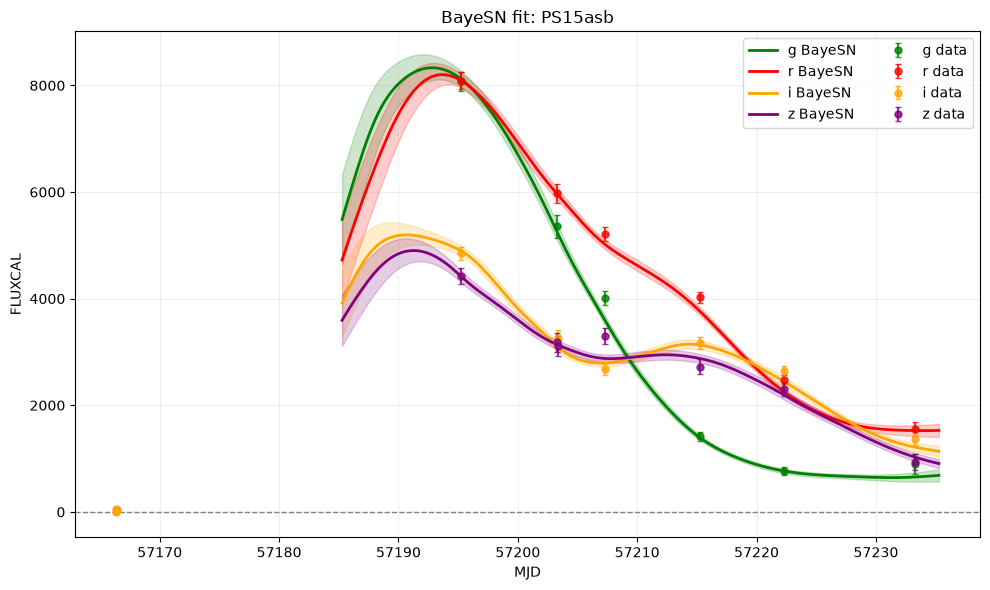

In [48]:
colors = {
    "g": "green",
    "r": "red",
    "i": "orange",
    "z": "purple",
}

fig, ax = plt.subplots(figsize=(10, 6))

for b_ind, band in enumerate(["g", "r", "i", "z"]):

    band_data = lc[
        lc["FLT"] == band
    ]

    # observed data
    ax.errorbar(
        band_data["MJD"],
        band_data["FLUXCAL"],
        yerr=band_data["FLUXCALERR"],
        fmt="o",
        markersize=5,
        capsize=2,
        color=colors[band],
        alpha=0.8,
        label=f"{band} data",
    )

    # BayeSN posterior mean
    ax.plot(
        plot_t,
        fit[b_ind],
        color=colors[band],
        linewidth=2,
        label=f"{band} BayeSN",
    )

    # posterior scatter
    ax.fill_between(
        plot_t,
        fit[b_ind] - fit_err[b_ind],
        fit[b_ind] + fit_err[b_ind],
        color=colors[band],
        alpha=0.2,
    )

ax.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel("MJD")
ax.set_ylabel("FLUXCAL")
ax.set_title(f"BayeSN fit: {snid}")

ax.legend(ncol=2)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Seeing how different redshifts and light curve quality impact LC fit

In [49]:
snids = [
    "SN2016coj",   # very low z
    "ASASSN-15od",
    "PS15asb",
    "PS15mt",
    "PS15adh",     # higher z
]

In [50]:
# Helper
from bayesn import SEDmodel
import numpy as np

filt_map = {
    "g": "g_PS1",
    "r": "r_PS1",
    "i": "i_PS1",
    "z": "z_PS1",
}

def fit_foundation_sn(snid):

    sn_file = (
        project_root
        / "data"
        / "Foundation_DR1_extracted"
        / "Foundation_DR1"
        / f"Foundation_DR1_{snid}.txt"
    )

    print(f"Fitting {snid}")
    print(sn_file)

    model = SEDmodel(
        load_model="T21_model"
    )

    samples, sn_props = model.fit_from_file(
        str(sn_file),
        filt_map=filt_map,
        photoz=False,
        chain_method="sequential",
    )

    return samples, sn_props

In [51]:
samples, sn_props = fit_foundation_sn(
    "SN2016coj"
)

Fitting SN2016coj
/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/Foundation_DR1_extracted/Foundation_DR1/Foundation_DR1_SN2016coj.txt
Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [02:01<00:00,  4.11it/s, 127 steps of size 3.80e-02. acc.
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:38<00:00,  5.10it/s, 63 steps of size 4.84e-02. acc. 
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.14      0.06      0.14      0.05      0.23    368.07      1.01
          Ds[0]     31.99      0.05     31.99     31.91     32.06    353.41      1.00
 eps_tform[0,0]      0.30      0.54      0.31     -0.60      1.13    590.63      1.00
 eps_tform[0,1]     -0.11      0.47     -0.13     -0.90      0.63    681.58      1.00
 eps_tform[0,2]     -0.21      0.47     -0.21     -1.01      0.48    804.14      1.00
 eps_tform[0,3]      0.20      0.55      0.18     -0.65      1.16    775.61      1.00
 eps_tform[0,4]      0.08      0.70      0.10     -1.21      1.14    527.50      1.00
 eps_tform[0,5]     -1.41      0.50     -1.41     -2.27     -0.66    707.99      1.00
 eps_tform[0,6]     -0.69      0.59     -0.70     -1.57      0.33    421.24      1.00
 eps_tform[0,7]     -1.24      0.43     -1.23     -1.91     -0.51    378.97      1.01
 eps_tform[0,8]     -1.78      0.64     -1.75     -2.

In [52]:
# Plotting helper

import matplotlib.pyplot as plt

def plot_foundation_fit(
    snid,
    samples,
    sn_props,
    num_samples=100,
    n_phase=80,
):

    # Fresh model because of the internal state issue
    plot_model = SEDmodel(
        load_model="T21_model"
    )

    t = np.linspace(
        -10,
        40,
        n_phase,
    )

    bands = [
        "g_PS1",
        "r_PS1",
        "i_PS1",
        "z_PS1",
    ]

    z, ebv_mw = sn_props

    flux_grid = plot_model.get_flux_from_chains(
        t,
        bands,
        samples,
        z,
        ebv_mw,
        mag=False,
        num_samples=num_samples,
    )

    fit = flux_grid.mean(axis=(0, 1))
    fit_err = flux_grid.std(axis=(0, 1))

    lc = (
        detections_df[
            detections_df["SNID"] == snid
        ]
        .sort_values("MJD")
        .copy()
    )

    peak_mjd = float(
        metadata_df.loc[
            metadata_df["SNID"] == snid,
            "SEARCH_PEAKMJD",
        ].iloc[0]
    )

    plot_t = (
        t + peak_mjd
    )

    colors = {
        "g": "green",
        "r": "red",
        "i": "orange",
        "z": "purple",
    }

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    for b_ind, band in enumerate(
        ["g", "r", "i", "z"]
    ):

        band_data = lc[
            lc["FLT"] == band
        ]

        ax.errorbar(
            band_data["MJD"],
            band_data["FLUXCAL"],
            yerr=band_data["FLUXCALERR"],
            fmt="o",
            markersize=5,
            capsize=2,
            color=colors[band],
            alpha=0.8,
            label=f"{band} data",
        )

        ax.plot(
            plot_t,
            fit[b_ind],
            color=colors[band],
            linewidth=2,
            label=f"{band} BayeSN",
        )

        ax.fill_between(
            plot_t,
            fit[b_ind] - fit_err[b_ind],
            fit[b_ind] + fit_err[b_ind],
            color=colors[band],
            alpha=0.2,
        )

    ax.axhline(
        0,
        color="gray",
        linestyle="--",
        linewidth=1,
    )

    ax.set_xlabel("MJD")
    ax.set_ylabel("FLUXCAL")
    ax.set_title(
        f"BayeSN fit: {snid}"
    )

    ax.legend(
        ncol=2,
        fontsize=9,
    )

    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

Fitting SN2016coj
/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/Foundation_DR1_extracted/Foundation_DR1/Foundation_DR1_SN2016coj.txt
Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:51<00:00,  4.50it/s, 127 steps of size 3.80e-02. acc.
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:37<00:00,  5.11it/s, 63 steps of size 4.84e-02. acc. 
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.14      0.06      0.14      0.05      0.23    368.07      1.01
          Ds[0]     31.99      0.05     31.99     31.91     32.06    353.41      1.00
 eps_tform[0,0]      0.30      0.54      0.31     -0.60      1.13    590.63      1.00
 eps_tform[0,1]     -0.11      0.47     -0.13     -0.90      0.63    681.58      1.00
 eps_tform[0,2]     -0.21      0.47     -0.21     -1.01      0.48    804.14      1.00
 eps_tform[0,3]      0.20      0.55      0.18     -0.65      1.16    775.61      1.00
 eps_tform[0,4]      0.08      0.70      0.10     -1.21      1.14    527.50      1.00
 eps_tform[0,5]     -1.41      0.50     -1.41     -2.27     -0.66    707.99      1.00
 eps_tform[0,6]     -0.69      0.59     -0.70     -1.57      0.33    421.24      1.00
 eps_tform[0,7]     -1.24      0.43     -1.23     -1.91     -0.51    378.97      1.01
 eps_tform[0,8]     -1.78      0.64     -1.75     -2.

100%|██████████████████████████████████████████████| 1/1 [00:08<00:00,  8.99s/it]


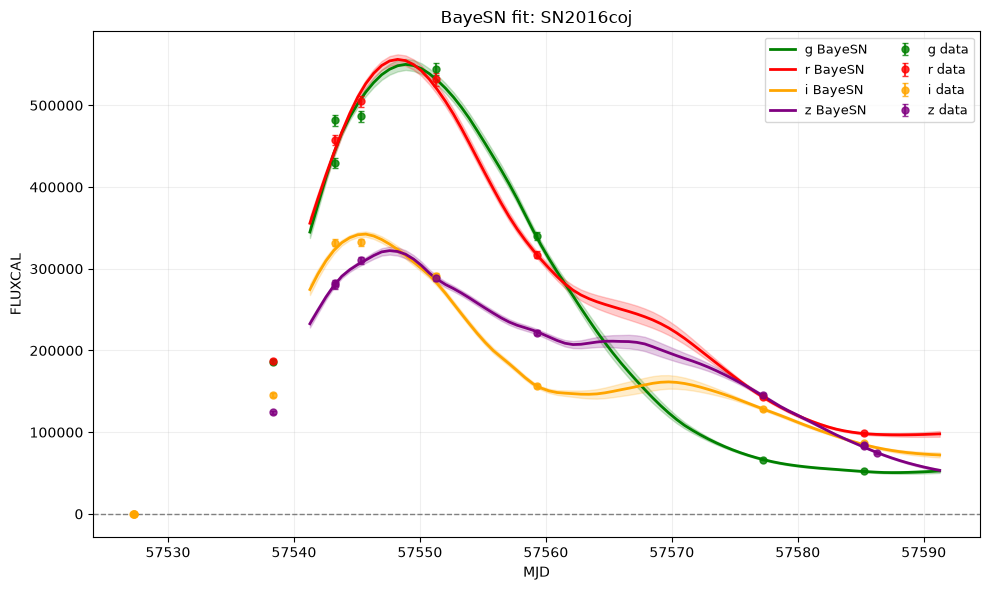

In [53]:
snid = "SN2016coj"

samples, sn_props = fit_foundation_sn(
    snid
)

plot_foundation_fit(
    snid,
    samples,
    sn_props,
    num_samples=100,
)

Fitting ASASSN-15od
/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/Foundation_DR1_extracted/Foundation_DR1/Foundation_DR1_ASASSN-15od.txt
Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:13<00:00,  6.78it/s, 127 steps of size 4.26e-02. acc.
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:06<00:00,  7.51it/s, 63 steps of size 5.36e-02. acc. 
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.06      0.04      0.06      0.00      0.12    625.67      1.00
          Ds[0]     34.38      0.04     34.38     34.30     34.45    555.45      1.00
 eps_tform[0,0]      0.29      0.92      0.28     -1.16      1.82   1184.08      1.00
 eps_tform[0,1]     -0.36      0.84     -0.37     -1.73      1.00    963.65      1.00
 eps_tform[0,2]     -0.20      0.89     -0.20     -1.64      1.25    830.96      1.00
 eps_tform[0,3]     -0.18      0.86     -0.16     -1.61      1.23   1178.48      1.00
 eps_tform[0,4]     -0.82      0.70     -0.76     -1.98      0.31    703.46      1.00
 eps_tform[0,5]      0.04      0.61      0.02     -0.98      0.98    874.37      1.00
 eps_tform[0,6]     -0.16      0.59     -0.18     -1.10      0.80    652.24      1.00
 eps_tform[0,7]     -0.57      0.48     -0.59     -1.38      0.20    576.82      1.00
 eps_tform[0,8]      0.23      0.84      0.22     -1.

100%|██████████████████████████████████████████████| 1/1 [00:01<00:00,  1.07s/it]


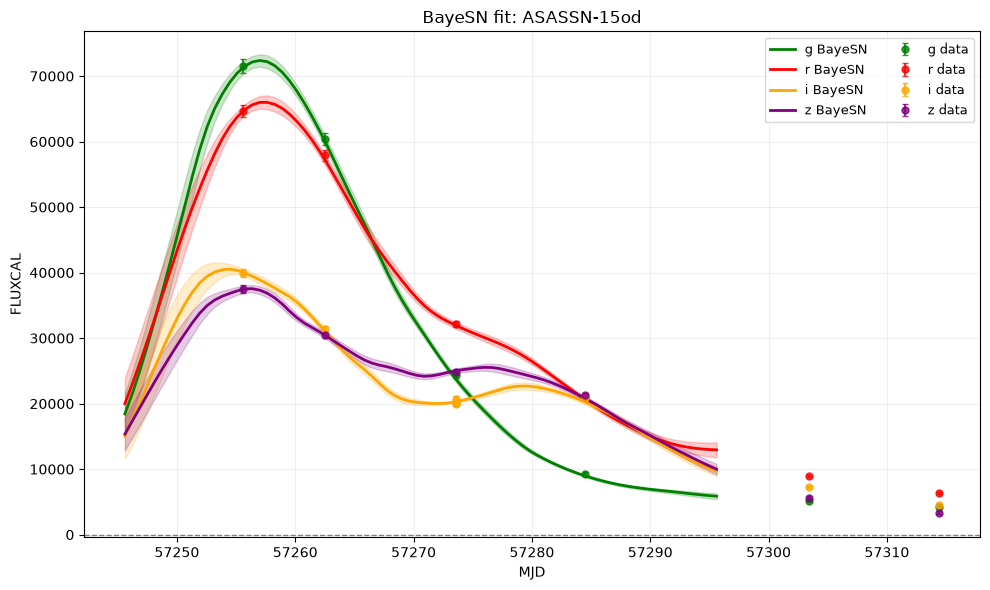

In [54]:
snid = "ASASSN-15od"

samples, sn_props = fit_foundation_sn(
    snid
)

plot_foundation_fit(
    snid,
    samples,
    sn_props,
)

Task was destroyed but it is pending!
task: <Task pending name='Task-326' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/jennakempster-taylor/miniforge3/envs/bayesn-lsst/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-327' coro=<Kernel.shell_main() running at /Users/jennakempster-taylor/miniforge3/envs/bayesn-lsst/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/jennakempster-taylor/miniforge3/envs/bayesn-lsst/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/jennakempster-taylor/miniforge3/envs/bayesn-lsst/lib/python3.11/site-packages/astropy/units/core.py:2423: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  for b_sub, p_sub in zip(b._bases, b._powers):
Task was destroyed but it is pending!
task: <Task pending name='Task-327' coro=<Kernel.shell_main() running at /Users/jennakempster-taylor/m

Fitting PS15asb
/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/Foundation_DR1_extracted/Foundation_DR1/Foundation_DR1_PS15asb.txt
Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [01:02<00:00,  7.99it/s, 63 steps of size 6.06e-02. acc. pr
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [00:53<00:00,  9.40it/s, 63 steps of size 5.54e-02. acc. pr
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at s


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.09      0.06      0.08      0.00      0.17    501.57      1.01
          Ds[0]     36.59      0.06     36.59     36.50     36.68    399.67      1.01
 eps_tform[0,0]     -0.56      0.87     -0.56     -2.03      0.82    963.92      1.00
 eps_tform[0,1]      1.02      0.77      1.00     -0.21      2.31    867.51      1.00
 eps_tform[0,2]     -0.03      0.86     -0.02     -1.59      1.27    999.53      1.00
 eps_tform[0,3]     -0.08      0.89     -0.03     -1.43      1.47   1061.51      1.00
 eps_tform[0,4]      1.09      0.72      1.11     -0.27      2.12    853.80      1.00
 eps_tform[0,5]     -0.16      0.77     -0.18     -1.34      1.16    840.71      1.00
 eps_tform[0,6]      0.95      0.76      0.93     -0.08      2.47    841.37      1.00
 eps_tform[0,7]     -0.83      0.69     -0.84     -1.90      0.38   1088.05      1.00
 eps_tform[0,8]     -1.45      0.76     -1.45     -2.

100%|████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.42s/it]


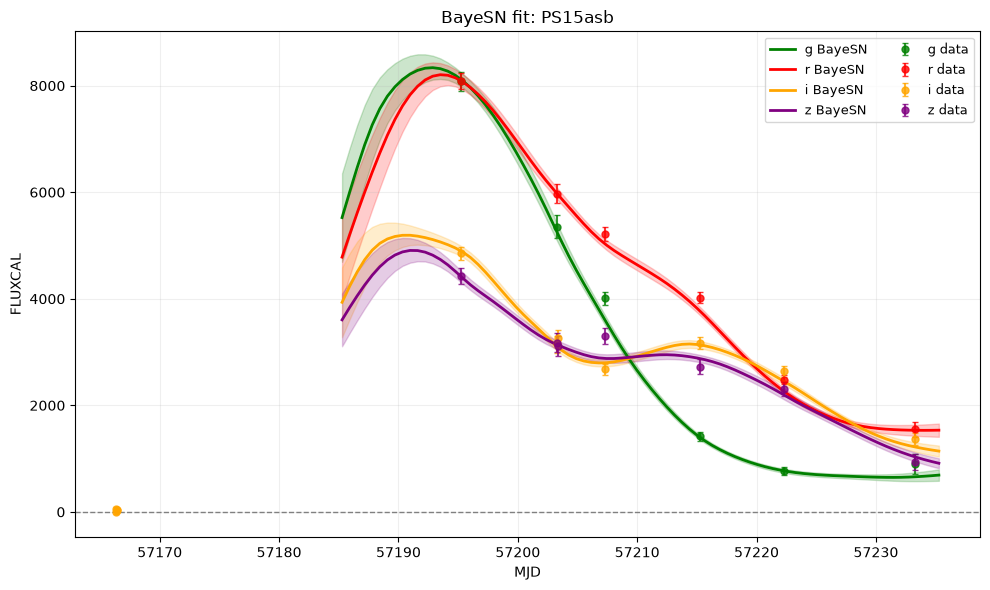

In [55]:
snid = "PS15asb"

samples, sn_props = fit_foundation_sn(
    snid
)

plot_foundation_fit(
    snid,
    samples,
    sn_props,
)



Fitting PS15mt
/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/Foundation_DR1_extracted/Foundation_DR1/Foundation_DR1_PS15mt.txt
Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [00:54<00:00,  9.15it/s, 63 steps of size 6.71e-02. acc. pr
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [00:47<00:00, 10.48it/s, 63 steps of size 7.38e-02. acc. pr
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at s


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.07      0.05      0.06      0.00      0.13    139.17      1.03
          Ds[0]     37.55      0.05     37.55     37.47     37.64    195.65      1.03
 eps_tform[0,0]     -0.21      0.71     -0.20     -1.40      0.91    423.05      1.00
 eps_tform[0,1]     -0.11      0.41     -0.14     -0.75      0.61    801.39      1.00
 eps_tform[0,2]      1.07      0.54      1.08      0.22      1.98    542.95      1.00
 eps_tform[0,3]      0.80      0.76      0.82     -0.46      2.03    892.28      1.00
 eps_tform[0,4]     -0.86      0.67     -0.83     -1.92      0.22    587.89      1.00
 eps_tform[0,5]      0.04      0.71     -0.00     -1.11      1.09    139.69      1.04
 eps_tform[0,6]      0.21      0.65      0.21     -0.87      1.21    354.60      1.01
 eps_tform[0,7]     -1.52      0.63     -1.52     -2.52     -0.47    844.49      1.00
 eps_tform[0,8]     -0.15      0.76     -0.18     -1.

100%|████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.14s/it]


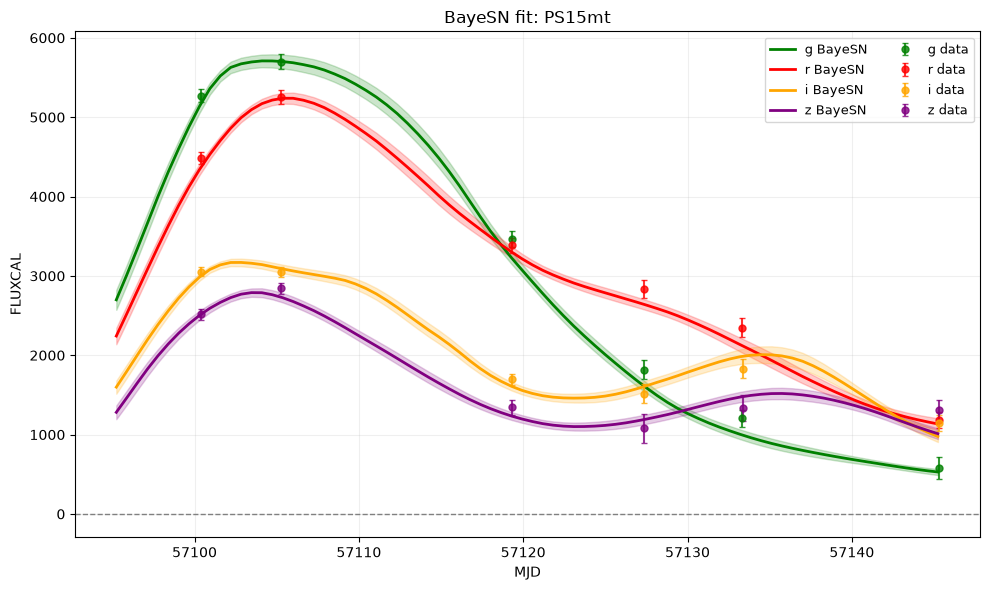

In [56]:
snid = "PS15mt"

samples, sn_props = fit_foundation_sn(
    snid
)

plot_foundation_fit(
    snid,
    samples,
    sn_props,
)



Fitting PS15adh
/Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/data/Foundation_DR1_extracted/Foundation_DR1/Foundation_DR1_PS15adh.txt
Current devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]
Currently working in /Users/jennakempster-taylor/Documents/bayesn-lsst/jkt-project/notebooks
Loading built-in model T21_model


/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [00:27<00:00, 18.12it/s, 31 steps of size 1.78e-01. acc. pr
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at site 'obs'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  mcmc.run(rng, data, band_weights, fix_tmax, fix_theta, theta_val, fix_AV, AV_val,
sample: 100%|█| 500/500 [00:25<00:00, 19.33it/s, 31 steps of size 1.60e-01. acc. pr
/Users/jennakempster-taylor/Documents/bayesn-lsst/bayesn/bayesn/bayesn_model.py:2792: UserWarning: Missing a plate statement for batch dimension -2 at s


                     mean       std    median      5.0%     95.0%     n_eff     r_hat
          AV[0]      0.06      0.05      0.05      0.00      0.13    756.93      1.00
          Ds[0]     38.27      0.08     38.28     38.15     38.40    469.69      1.00
 eps_tform[0,0]     -0.17      1.00     -0.20     -1.62      1.56   1691.95      1.00
 eps_tform[0,1]     -0.36      0.92     -0.39     -1.90      1.12   1540.03      1.00
 eps_tform[0,2]     -0.12      0.93     -0.12     -1.77      1.29   1398.58      1.00
 eps_tform[0,3]     -0.41      0.95     -0.35     -2.06      1.08   1382.27      1.00
 eps_tform[0,4]     -0.91      0.81     -0.93     -2.28      0.39   1123.38      1.00
 eps_tform[0,5]      0.05      0.89      0.04     -1.31      1.50   1225.61      1.00
 eps_tform[0,6]     -0.58      0.91     -0.57     -2.13      0.81   1062.54      1.00
 eps_tform[0,7]     -0.13      0.96     -0.11     -1.70      1.37   1140.67      1.00
 eps_tform[0,8]     -0.15      0.94     -0.15     -1.

100%|████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.08s/it]


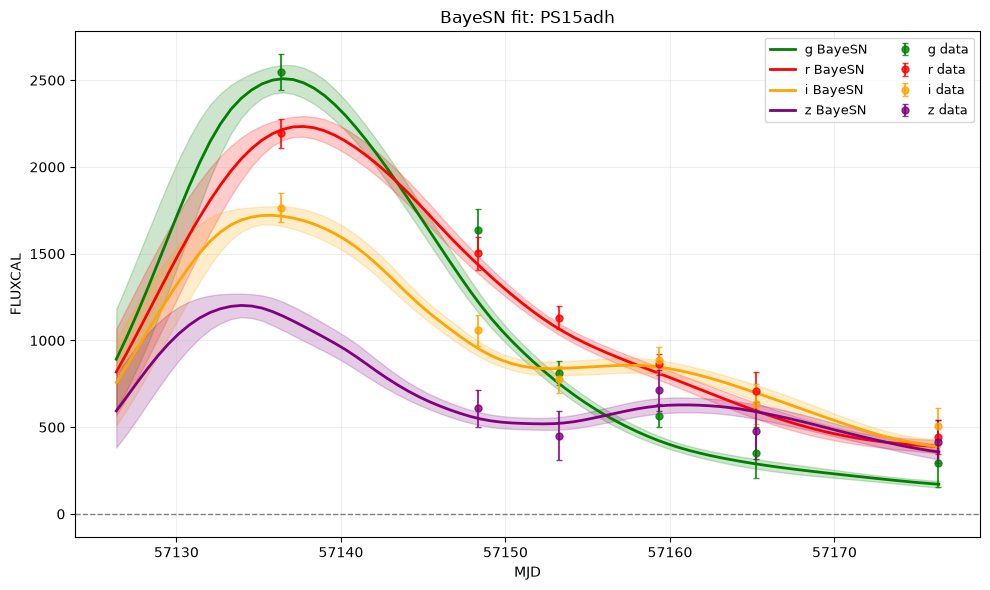

In [57]:
snid = "PS15adh"

samples, sn_props = fit_foundation_sn(
    snid
)

plot_foundation_fit(
    snid,
    samples,
    sn_props,
)



In [58]:
eps_keys = [
    key for key in samples
    if key.startswith("eps")
]

In [59]:
eps = np.asarray(samples["eps_tform"])
print(eps.shape)

(4, 250, 1, 24)


In [60]:
eps_flat = eps.reshape(-1, eps.shape[-1])

eps_median = np.median(
    eps_flat,
    axis=0,
)

In [61]:
max_abs_eps = np.max(
    np.abs(eps_median)
)

rms_eps = np.sqrt(
    np.mean(eps_median**2)
)

print("max |epsilon|:", max_abs_eps)
print("RMS epsilon:", rms_eps)

max |epsilon|: 0.9284813292724015
RMS epsilon: 0.34585497432922413


In [62]:
plt.scatter(
    coverage_df["n_observations"],
    fit_results["max_abs_eps"]
)

NameError: name 'fit_results' is not defined

In [63]:
eps = np.asarray(samples["eps_tform"])

print(eps.shape)
eps_flat = eps.reshape(-1, eps.shape[-1])

eps_q05 = np.percentile(eps_flat, 5, axis=0)
eps_med = np.percentile(eps_flat, 50, axis=0)
eps_q95 = np.percentile(eps_flat, 95, axis=0)

(4, 250, 1, 24)


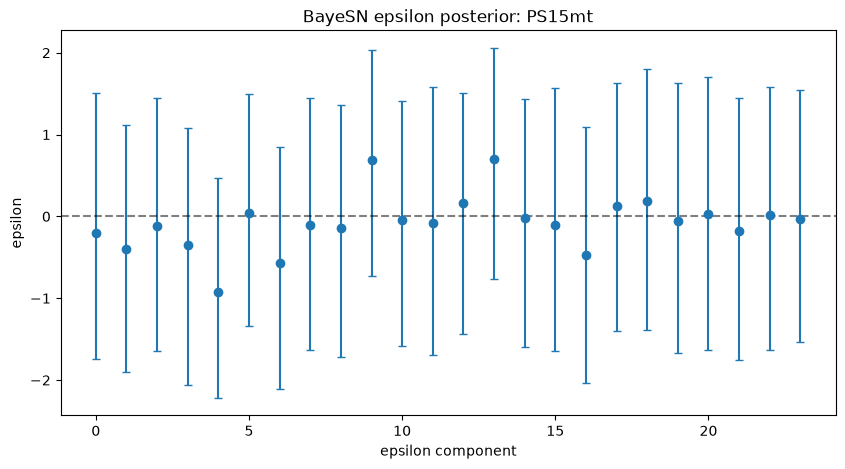

In [67]:
x = np.arange(len(eps_med))

plt.figure(figsize=(10, 5))

plt.errorbar(
    x,
    eps_med,
    yerr=[
        eps_med - eps_q05,
        eps_q95 - eps_med,
    ],
    fmt="o",
    capsize=3,
)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    alpha=0.5,
)

plt.xlabel("epsilon component")
plt.ylabel("epsilon")
plt.title(f"BayeSN epsilon posterior: {'PS15mt'}")

plt.show()